# **Trends in Open-Source AI Models on Public Model Hubs**

### Domain : Artificial Intelligence (AI)

### Objective :


*   Analyze AI model adoption trends using download metrics to identify the most popular and fast-growing models.

*  Examine the geographic distribution of AI model development across countries and organizations.

*  Compare model modalities (Text, Image, Audio, Video, Multimodal) and study their usage patterns.

*  Identify the role of contributor types (users, teams, companies, free/community) in AI model creation.


*  Investigate model lineage and derivation, understanding how base models are reused or fine-tuned.


*   Perform time-based analysis to observe model release patterns and ecosystem growth over time.














### Dataset Information :
#####Source : Hugging Face (Open-Source Model Hub)
#####Organization : Hugging Face Community (Global Open-Source AI Organizations and Independent Contributors)
#####TimeLine : Rolling snapshots of model metadata collected between 2025 and 2026

###Problem Definition :
The rapid growth of open-source and publicly available AI models has created a highly diverse ecosystem with variations in model types, modalities, languages, contributors, and geographic origins. However, this information is often scattered and difficult to interpret without systematic analysis.

This project addresses the problem by using Python-based data analysis techniques to clean, explore, and visualize AI model metadata, enabling data-driven insights into trends, gaps, and growth patterns within the AI model landscape.

###Importing Libraries

In [ ]:
import pandas as pd                 # pandas for data manipulation
import numpy as np                  # numpy for numerical operations
import matplotlib.pyplot as plt     # for basic visualizations
import seaborn as sns               # for advanced visualizations
import plotly.express as px         # for interactive visualizations
import warnings                     # to handle warnings
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:,.0f}'.format


###Loading the Dataset

In [ ]:
data_url = "https://raw.githubusercontent.com/shalini-k-git/open-source-ai-model-hub-trends/main/data/one_year_rolling.xlsx"

#Using pandas to load the dataset as dataframe 'df'
df = pd.read_excel(data_url)

#**Exploratory  Data Analysis**

In [ ]:
# Display first 5 rows of the dataset
df.head()

,_id,model,author,time,created,downloadsAllTime,annotator,org_model,org_type,org_country,derived_author,org_country_single,derived_org_country,derived_org_country_single,merged_country_groups_single,merged_derived_country_groups_single,merged_derived_from,merged_languages,merged_modality
0,67be03c930eecba21c83a91e,Kijai/WanVideo_comfy,Kijai,2026-01-12,2025-02-25 17:54:17,31433170,7,user,user,['user'],Wan-AI,user,['China'],China,User,China,['Wan-AI/Wan2.1-VACE-1.3B'],['Unknown'],Image --> Video
1,680da718233834890aa01f51,Qwen/Qwen3-0.6B,Qwen,2026-01-12,2025-04-27 03:40:08,43715440,3,team,company,['China'],Qwen,China,['China'],China,China,China,['Qwen/Qwen3-0.6B-Base'],['Multilingual'],Text --> Text
2,680a289582ee1640eea64f70,ResembleAI/chatterbox,ResembleAI,2026-01-12,2025-04-24 12:03:33,5870348,3,user,user,['user'],ResembleAI,user,['user'],user,User,User,['No'],['English'],Text --> Audio
3,68378cef5cbef05290b4d045,black-forest-labs/FLUX.1-Kontext-dev,black-forest-labs,2026-01-12,2025-05-28 22:23:43,2223857,3,team,company,['Germany'],black-forest-labs,Germany,['Germany'],Germany,Germany,Germany,['enhanceaiteam/FLUX.1-Pro'],['English'],Image + Text --> Image
4,678dc6fff905d106be796d8a,deepseek-ai/DeepSeek-R1,deepseek-ai,2026-01-12,2025-01-20 03:46:07,13689568,6,free,company,['China'],deepseek-ai,China,['China'],China,China,China,['deepseek-ai/DeepSeek-V3-Base'],['English' 'Mandarin Chinese'],Text --> Text


In [ ]:
#Display last 5 rows of the dataset
df.tail()

,_id,model,author,time,created,downloadsAllTime,annotator,org_model,org_type,org_country,derived_author,org_country_single,derived_org_country,derived_org_country_single,merged_country_groups_single,merged_derived_country_groups_single,merged_derived_from,merged_languages,merged_modality
19356,6864538be3f77b26a1c004eb,lmstudio-community/gemma-3n-E4B-it-MLX-6bit,lmstudio-community,2026-02-01,2025-07-01 21:30:51,1330989,3,team,community,['Online'],google,Online,['United States of America'],United States of America,International / Online,USA,['google/gemma-3n-E4B-it'],['English'],Audio + Image + Text + Video --> Text
19357,68645413038e60b4fe07ec63,lmstudio-community/gemma-3n-E4B-it-MLX-8bit,lmstudio-community,2026-02-01,2025-07-01 21:33:07,1339132,3,team,community,['Online'],google,Online,['United States of America'],United States of America,International / Online,USA,['google/gemma-3n-E4B-it'],['Multilingual'],Audio + Image + Text + Video --> Text
19358,6867e3f036e90a4761150310,mistralai/Devstral-Small-2507,mistralai,2026-02-01,2025-07-04 14:23:44,216560,2,team,company,['France'],mistralai,France,['France'],France,France,France,['mistralai/Mistral-Small-3.1-24B-Instruct-2503'],['French' 'English' 'Romanian' 'Polish' 'Serbi...,Text --> Text
19359,686b8447d32259a67c616c1f,datumo/E-Star-12B-v0.2,datumo,2026-02-01,2025-07-07 08:24:39,8560,0,user,user,['user'],datumo,user,['user'],user,User,User,[],['Unknown'],Undocumented --> Undocumented
19360,686bc43f381f3d0f775a7d17,docling-project/docling-layout-old,ds4sd,2026-02-01,2025-07-07 12:57:35,511582,1,enterprise,NaN,['Switzerland'],ds4sd,Switzerland,['Switzerland'],Switzerland,Rest of Europe,Rest of Europe,['No'],['English'],Image --> Image


In [ ]:
# Display the number of rows and columns
df.shape

(19361, 19)

In [ ]:
#The one shot summary of numerical columns in the dataset
df.describe()

,time,created,downloadsAllTime,annotator
count,19361,19361,"19,361","19,361"
mean,2025-08-21 17:13:27.540932608,2025-01-09 21:23:25.934404608,"2,019,290",7
min,2025-02-26 00:00:00,2024-02-26 14:12:03,0,0
25%,2025-05-21 00:00:00,2024-10-25 06:24:15,"16,346",3
50%,2025-08-13 00:00:00,2025-01-20 14:52:51,"195,057",6
75%,2025-12-03 00:00:00,2025-04-07 18:47:10,"831,487",10
max,2026-02-01 00:00:00,2025-07-11 00:55:12,"112,441,617",14
std,NaN,NaN,"7,076,267",4


In [ ]:
#Overall information of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19361 entries, 0 to 19360
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   _id                                   19361 non-null  object        
 1   model                                 19361 non-null  object        
 2   author                                19361 non-null  object        
 3   time                                  19361 non-null  datetime64[ns]
 4   created                               19361 non-null  datetime64[ns]
 5   downloadsAllTime                      19361 non-null  int64         
 6   annotator                             19361 non-null  int64         
 7   org_model                             19361 non-null  object        
 8   org_type                              18442 non-null  object        
 9   org_country                           19361 non-null  object        
 10

In [ ]:
#Checking any existing null values in the dataset
df.isna().sum()

,0
_id,0
model,0
author,0
time,0
created,0
downloadsAllTime,0
annotator,0
org_model,0
org_type,919
org_country,0


In [ ]:
#Checking for the datatypes of each column
df.dtypes

,0
_id,object
model,object
author,object
time,datetime64[ns]
created,datetime64[ns]
downloadsAllTime,int64
annotator,int64
org_model,object
org_type,object
org_country,object


In [ ]:
#Displaying the column names
df.columns

Index(['_id', 'model', 'author', 'time', 'created', 'downloadsAllTime',
       'annotator', 'org_model', 'org_type', 'org_country', 'derived_author',
       'org_country_single', 'derived_org_country',
       'derived_org_country_single', 'merged_country_groups_single',
       'merged_derived_country_groups_single', 'merged_derived_from',
       'merged_languages', 'merged_modality'],
      dtype='object')

In [ ]:
#Checking for the sum of duplicate columns
df['model'].duplicated().sum()

np.int64(18811)

In [ ]:
#Checking for the number of unqiue columns
df['model'].nunique()

550

The _id column serves as the primary unique identifier for models. Although multiple rows share the same _id, each represents the same model observed at different time points, enabling temporal analysis rather than indicating data duplication.

In [ ]:
#Checking for value counts
df['merged_modality'].value_counts()

,count
merged_modality,
Text --> Text,7677
Text --> Image,5753
Image + Text --> Text,1296
Image + Text --> Image,494
Text --> Video,417
Image --> Image,403
Text --> Audio,364
Image --> Video,321
Text --> Text Embed/Class,285


In [ ]:
#Checking the different types of model
df['model'].value_counts()

,count
model,
SparkAudio/Spark-TTS-0.5B,71
calcuis/wan-gguf,71
Zyphra/Zonos-v0.1-transformer,71
Wan-AI/Wan2.1-T2V-14B,71
Wan-AI/Wan2.1-I2V-14B-720P,71
...,...
Bingsu/yolo-world-mirror,1
stabilityai/TripoSR,1
argmaxinc/whisperkit-coreml,1


#**Data Cleaning**

In [ ]:
#Copying the data in a new dataframe to preserve the raw data as it is
df_raw = df.copy()

In [ ]:
#Creating a new dataframe to work on cleaning
#Selecting only the necessary and relevant columns to avoid redundancy

#Store the necessary columns in a list before creating a new df
final_columns = [
    '_id',
    'model',
    'author',
    'created',
    'time',
    'downloadsAllTime',
    'annotator',
    'org_model',
    'org_type',
    'org_country_single',
    'derived_org_country_single',
    'merged_country_groups_single',
    'merged_derived_country_groups_single',
    'derived_author',
    'merged_derived_from',
    'merged_languages',
    'merged_modality'
]

# Creating the copy for analysis
df_cleaned = df[final_columns].copy()

# Renaming few columns for better understanding
df_cleaned  = df_cleaned.rename(columns={'_id': 'id',
                                    'org_model': 'access_tier',
                                    'org_country_single': 'org_country',
                                    'merged_country_groups_single': 'org_country_grouped',
                                    'derived_org_country_single': 'derived_model_country',
                                    'merged_derived_country_groups_single': 'derived_country_grouped',
                                    'merged_derived_from': 'model_derived_from',
                                    'merged_languages': 'model_languages',
                                    'merged_modality': 'model_modality'
                                     })

# Preview the final dataset
df_cleaned.head()


,id,model,author,created,time,downloadsAllTime,annotator,access_tier,org_type,org_country,derived_model_country,org_country_grouped,derived_country_grouped,derived_author,model_derived_from,model_languages,model_modality
0,67be03c930eecba21c83a91e,Kijai/WanVideo_comfy,Kijai,2025-02-25 17:54:17,2026-01-12,31433170,7,user,user,user,China,User,China,Wan-AI,['Wan-AI/Wan2.1-VACE-1.3B'],['Unknown'],Image --> Video
1,680da718233834890aa01f51,Qwen/Qwen3-0.6B,Qwen,2025-04-27 03:40:08,2026-01-12,43715440,3,team,company,China,China,China,China,Qwen,['Qwen/Qwen3-0.6B-Base'],['Multilingual'],Text --> Text
2,680a289582ee1640eea64f70,ResembleAI/chatterbox,ResembleAI,2025-04-24 12:03:33,2026-01-12,5870348,3,user,user,user,user,User,User,ResembleAI,['No'],['English'],Text --> Audio
3,68378cef5cbef05290b4d045,black-forest-labs/FLUX.1-Kontext-dev,black-forest-labs,2025-05-28 22:23:43,2026-01-12,2223857,3,team,company,Germany,Germany,Germany,Germany,black-forest-labs,['enhanceaiteam/FLUX.1-Pro'],['English'],Image + Text --> Image
4,678dc6fff905d106be796d8a,deepseek-ai/DeepSeek-R1,deepseek-ai,2025-01-20 03:46:07,2026-01-12,13689568,6,free,company,China,China,China,China,deepseek-ai,['deepseek-ai/DeepSeek-V3-Base'],['English' 'Mandarin Chinese'],Text --> Text


In [ ]:
#Dealing with Data types of date columns and numeric values using pandas library

#snapshot date - Explicitly parsing this date column to datetime
df_cleaned['time'] = pd.to_datetime(df_cleaned['time'])

#Model creation timestamp - Explicitly parsing this date column to datetime
df_cleaned['created'] = pd.to_datetime(df_cleaned['created'])

#Converting the number of downloads column to numeric datatype
df_cleaned['downloadsAllTime'] = pd.to_numeric(df_cleaned['downloadsAllTime'], errors='coerce')


In [ ]:
#Converting the 'model_languages' column into a proper list

#Regular Expression Library
import re

#Function declaration
def to_list(value):
    # If it's already a list, return as-is
    if isinstance(value, list):
        return value

    # Extract text inside single quotes
    languages = re.findall(r"'(.*?)'", value)

    return languages if languages else ['Unknown']


In [ ]:
#Calling the function to convert the column into a proper list
df_cleaned['model_languages'] = df_cleaned['model_languages'].apply(to_list)

In [ ]:
#Displaying the last 5 rows to check the made changes
df_cleaned['model_languages'].tail()

,model_languages
19356,[English]
19357,[Multilingual]
19358,"[French, English, Romanian, Polish, Serbian, J..."
19359,[Unknown]
19360,[English]


In [ ]:
#Standarizing the country names
#Setting new standarized values in places of old inconsistent values
country = {
    'United States of America': 'USA',
    'United States': 'USA',
    'user' : 'User'
}

df_cleaned['org_country'] = df_cleaned['org_country'].replace(country)
df_cleaned['org_country_grouped'] = df_cleaned['org_country_grouped'].replace(country)
df_cleaned['derived_model_country'] = df_cleaned['derived_model_country'].replace(country)
df_cleaned['derived_country_grouped'] = df_cleaned['derived_country_grouped'].replace(country)


In [ ]:
#Standarizing the columns
df_cleaned['org_type'] = df_cleaned['org_type'].str.capitalize()
df_cleaned['access_tier'] = df_cleaned['access_tier'].str.capitalize()

In [ ]:
#Dealing with 'org type' which has null values
df_cleaned['org_type'].isna().sum()

np.int64(919)

In [ ]:
#Finding the most frequent value in 'org type' column'
mode_org_type = df_cleaned['org_type'].mode()[0]
mode_org_type

'User'

In [ ]:
#Filling the empty rows using the most frequently occuring value, that is 'user'
df_cleaned['org_type'] = df_cleaned['org_type'].fillna(mode_org_type)

In [ ]:
#After dealing with null values
df_cleaned['org_type'].isna().sum()

np.int64(0)

In [ ]:
#Checking for any existing null values
df_cleaned.isna().sum()

,0
id,0
model,0
author,0
created,0
time,0
downloadsAllTime,0
annotator,0
access_tier,0
org_type,0
org_country,0


In [ ]:
#Function to clean the model

#Using Abstract Syntax Trees Library
import ast

def clean_derived_from(value):
    # Missing values
    if pd.isna(value):
        return ['Unknown']

    # If already a list
    if isinstance(value, list):
        if len(value) == 0:
            return ['Unknown']
        if value in [['No'], ['Unsure']]:                 #If the value is empty or 'No' or 'Unsure', return 'Unknown'
            return ['Unknown']
        return value

    # If string representation of a list
    if isinstance(value, str):
        try:                                              #Error Handling
            parsed = ast.literal_eval(value)              #Using ast library to parse the value into list
            if isinstance(parsed, list):
                if len(parsed) == 0 or parsed in [['No'], ['Unsure']]:    #If the value is empty or 'No' or 'Unsure', return 'Unknown'
                    return ['Unknown']
                return parsed                             #Return the parsed list
        except:
            pass

    return ['Unknown']


In [ ]:
#Using the above function to clean the column
df_cleaned['model_derived_from'] = df_cleaned['model_derived_from'].apply(clean_derived_from)

In [ ]:
#Checking whether the raw data is safe and unaffected
df_raw.equals(df_cleaned) #False shows df_finals have changes

False

In [ ]:
#Checking the number of rows and columns in raw df
df_raw.shape

(19361, 19)

In [ ]:
#Checking the number of rows and columns in final df
df_cleaned.shape   #Few columns are eliminated as it was irrelevant and redundant for analysis

(19361, 17)

In [ ]:
df_cleaned.head()

,id,model,author,created,time,downloadsAllTime,annotator,access_tier,org_type,org_country,derived_model_country,org_country_grouped,derived_country_grouped,derived_author,model_derived_from,model_languages,model_modality
0,67be03c930eecba21c83a91e,Kijai/WanVideo_comfy,Kijai,2025-02-25 17:54:17,2026-01-12,31433170,7,User,User,User,China,User,China,Wan-AI,[Wan-AI/Wan2.1-VACE-1.3B],[Unknown],Image --> Video
1,680da718233834890aa01f51,Qwen/Qwen3-0.6B,Qwen,2025-04-27 03:40:08,2026-01-12,43715440,3,Team,Company,China,China,China,China,Qwen,[Qwen/Qwen3-0.6B-Base],[Multilingual],Text --> Text
2,680a289582ee1640eea64f70,ResembleAI/chatterbox,ResembleAI,2025-04-24 12:03:33,2026-01-12,5870348,3,User,User,User,User,User,User,ResembleAI,[Unknown],[English],Text --> Audio
3,68378cef5cbef05290b4d045,black-forest-labs/FLUX.1-Kontext-dev,black-forest-labs,2025-05-28 22:23:43,2026-01-12,2223857,3,Team,Company,Germany,Germany,Germany,Germany,black-forest-labs,[enhanceaiteam/FLUX.1-Pro],[English],Image + Text --> Image
4,678dc6fff905d106be796d8a,deepseek-ai/DeepSeek-R1,deepseek-ai,2025-01-20 03:46:07,2026-01-12,13689568,6,Free,Company,China,China,China,China,deepseek-ai,[deepseek-ai/DeepSeek-V3-Base],"[English, Mandarin Chinese]",Text --> Text


#**Data Pre-Processing**
As part of data preprocessing, the cleaned dataset was split into df_master, a panel dataset containing time-series observations for lifecycle and growth analysis, and df_models, a cross-sectional dataset with one row per model for structural and statistical comparison.


### Creation of Panel dataframe for Time-Series Analysis

In [ ]:
df_master = df_cleaned[[
    'id',
    'model',
    'author',
    'created',
    'time',
    'downloadsAllTime',
    'org_country',
    'org_type',
    'model_modality'
]].copy()

In [ ]:
#Deriving model names seperate from author
df_master['model_name']= df_master['model'].str.split('/', n=1).str[1]
#Placing the model name column in 3rd position
df_master.insert(3, 'model_name', df_master.pop('model_name'))

In [ ]:
#Sort Values
df_master = df_master.sort_values(['model', 'time'])

In [ ]:
#Model Age Days and Weeks
df_master['model_age_days'] = (df_master['time'] - df_master['created']).dt.days
df_master['model_age_weeks'] = (df_master['model_age_days'] / 7).astype(int)
df_master['model_age_months'] = df_master['model_age_days'] / 30

In [ ]:
#Model Age Bucket
df_master['age_stage'] = pd.cut(df_master['model_age_weeks'],bins=[0,4,12,26,52,200],labels=['Launch','Early Growth','Growth','Mature','Old'])

In [ ]:
#Weekly growth
df_master['weekly_growth'] = df_master.groupby('model')['downloadsAllTime'].diff().fillna(0)

In [ ]:
#Downloads per month
df_master['downloads_per_month'] = np.where(
    df_master['model_age_months'] > 0,
    df_master['downloadsAllTime'] / df_master['model_age_months'],
    df_master['downloadsAllTime']
)

In [ ]:
df_master.head()

,id,model,author,model_name,created,time,downloadsAllTime,org_country,org_type,model_modality,model_age_days,model_age_weeks,model_age_months,age_stage,weekly_growth,downloads_per_month
14150,6651802a815d7642d5aaef56,2Noise/ChatTTS,2Noise,ChatTTS,2024-05-25 06:07:38,2025-02-26,138273,User,User,Text --> Audio,276,39,9,Mature,0,"15,030"
14568,6651802a815d7642d5aaef56,2Noise/ChatTTS,2Noise,ChatTTS,2024-05-25 06:07:38,2025-03-05,139063,User,User,Text --> Audio,283,40,9,Mature,790,"14,742"
14945,6651802a815d7642d5aaef56,2Noise/ChatTTS,2Noise,ChatTTS,2024-05-25 06:07:38,2025-03-12,139702,User,User,Text --> Audio,290,41,10,Mature,639,"14,452"
15323,6651802a815d7642d5aaef56,2Noise/ChatTTS,2Noise,ChatTTS,2024-05-25 06:07:38,2025-03-19,140911,User,User,Text --> Audio,297,42,10,Mature,"1,209","14,233"
9650,6651802a815d7642d5aaef56,2Noise/ChatTTS,2Noise,ChatTTS,2024-05-25 06:07:38,2025-03-26,141501,User,User,Text --> Audio,304,43,10,Mature,590,"13,964"


###Creation of Individual Models Dataframe for Static Analysis

In [ ]:
#Saving unique models in a new dataframe
df_models = df_cleaned.groupby('model').tail(1).reset_index(drop=True)

In [ ]:
#Rename 'downloadsAllTime' into total_downloads
df_models = df_models.rename(columns={'downloadsAllTime': 'total_downloads'})

In [ ]:
df_models.shape

(550, 17)

Feature Engineering

In [ ]:
#Is model derived by same author or dereived author
df_models['same_author_derived'] = (df_models['author'] == df_models['derived_author']).astype(int)

In [ ]:
#A cloumn to check whether the existing model has an ancestral model or generated from scratch
df_models['has_known_lineage'] = df_models['model_derived_from'].apply(
    lambda x: x != ['Unknown']
)

In [ ]:
#Deriving model name from model
df_models['model_name'] = df_models['model'].str.split('/').str[1]
df_models.insert(3,'model_name', df_models.pop('model_name'))

In [ ]:
#Does it take more than 1 inputs
df_models['is_multimodal_input'] = df_models['model_modality'].str.split('-->').str[0].str.strip().apply(
    lambda x: True if '+' in x else False
)

In [ ]:
#Checking whether the model is actively used
df_models['is_active_model'] = (df_models['total_downloads'] > 0).astype(int)

In [ ]:
df_models.head()

,id,model,author,model_name,created,time,total_downloads,annotator,access_tier,org_type,...,org_country_grouped,derived_country_grouped,derived_author,model_derived_from,model_languages,model_modality,same_author_derived,has_known_lineage,is_multimodal_input,is_active_model
0,66abe4b6f91b4bb4e551da79,Kijai/flux-fp8,Kijai,flux-fp8,2024-08-01 19:40:38,2025-07-30,0,14,User,User,...,User,Germany,black-forest-labs,[black-forest-labs/FLUX.1-devblack-forest-labs...,[English],Image + Text --> Image,0,True,True,0
1,66ae8d4edb3168f9d1753958,Comfy-Org/flux1-dev,comfy,flux1-dev,2024-08-03 20:04:30,2025-07-30,0,10,User,Company,...,USA,USA,comfy,[Unknown],[English],Image + Text --> Image,1,False,True,0
2,66afcaacb9803b78f0616be8,Comfy-Org/flux1-schnell,comfy,flux1-schnell,2024-08-04 18:38:36,2025-07-30,0,10,User,Company,...,USA,USA,comfy,[Unknown],[Unknown],Text --> Image,1,False,False,0
3,66d0dccb3866d4d3087d3a9f,Comfy-Org/stable-diffusion-v1-5-archive,comfy,stable-diffusion-v1-5-archive,2024-08-29 20:40:43,2025-08-27,790460,6,User,Company,...,USA,Germany,CompVis,[CompVis/stable-diffusion-v1-4],[English],Text --> Image,0,True,False,1
4,66e79eb10cd314a638cf0148,zai-org/CogVideoX-5b-I2V,zai-org,CogVideoX-5b-I2V,2024-09-16 02:57:53,2025-09-10,942002,4,User,User,...,User,User,zai-org,[THUDM/CogVideoX-5b],[English],Image + Text --> Video,1,True,True,1


# Statistical Analysis and Visualization

###Model Level Analysis

In [ ]:
#Display number of rows and columns
df_models.shape

(550, 22)

In [ ]:
#Summary of dataframe
df_models.describe()

,created,time,total_downloads,annotator,same_author_derived,is_active_model
count,550,550,550,550,550,550
mean,2024-10-30 21:23:57.016363776,2025-08-17 03:42:32.727272704,"2,566,133",7,0,1
min,2024-02-26 14:12:03,2025-02-26 00:00:00,0,0,0,0
25%,2024-08-07 21:42:57.750000128,2025-03-19 00:00:00,"12,830",3,0,1
50%,2024-11-03 17:07:54,2025-10-22 00:00:00,"154,702",8,0,1
75%,2025-02-04 14:40:15,2026-01-20 00:00:00,"885,485",10,1,1
max,2025-07-11 00:55:12,2026-02-01 00:00:00,"102,140,662",14,1,1
std,NaN,NaN,"9,046,057",4,0,0


##Statistical Analysis

In [ ]:
#Extracting Numerical Columns
numerical_cols = df_models[['total_downloads','annotator']]

In [ ]:
#Measure of central tendency
central_tendency = pd.DataFrame({
    'Mean' : numerical_cols.mean(),
    'Median' : numerical_cols.median(),
})
central_tendency

,Mean,Median
total_downloads,"2,566,133","154,702"
annotator,7,8


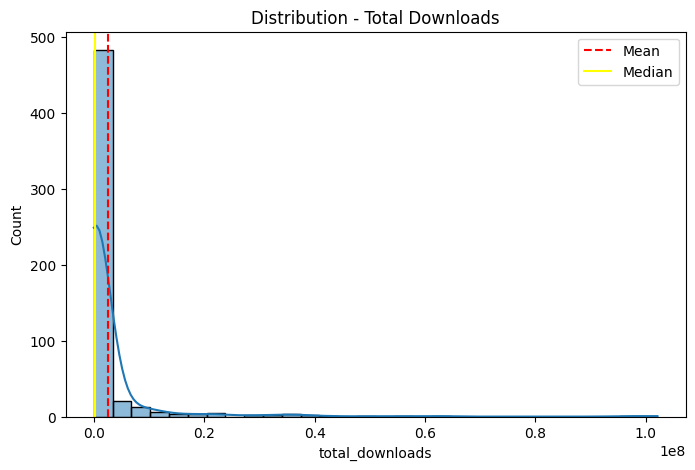

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_models['total_downloads'], kde=True, bins=30)
plt.axvline(df_models['total_downloads'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df_models['total_downloads'].median(),color='yellow', linestyle='-', label='Median')
plt.title("Distribution - Total Downloads")
plt.legend()
plt.show()


In [ ]:
#Variance and Standard Deviation
stat = pd.DataFrame({
    'Variance' : numerical_cols.var(),
    'Standard Variation' : numerical_cols.std()
})
stat

,Variance,Standard Variation
total_downloads,"81,831,143,298,918","9,046,057"
annotator,17,4


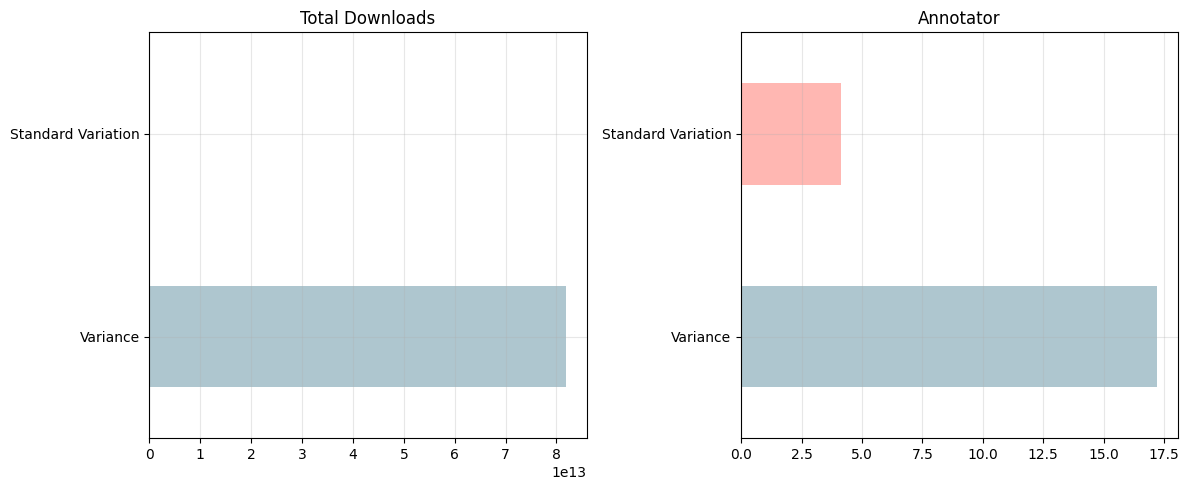

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Variance
stat.loc['total_downloads'].plot(
    kind='barh',
    ax=axes[0],
    color=['#AEC6CF', '#FFB7B2']
)
axes[0].set_title("Total Downloads")
axes[0].grid(alpha=0.3)

# Standard Deviation
stat.loc['annotator'].plot(
    kind='barh',
    ax=axes[1],
    color=['#AEC6CF', '#FFB7B2']
)
axes[1].set_title("Annotator")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#Kurtosis and Skewness
skew_stat = pd.DataFrame({
    'Kurtosis' : numerical_cols.kurt(),
    'Skewness' : numerical_cols.skew()
})
skew_stat

,Kurtosis,Skewness
total_downloads,57,7
annotator,-1,-0


<Figure size 1200x600 with 0 Axes>

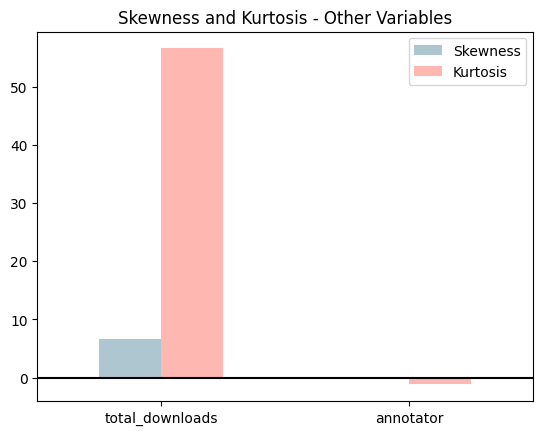

In [ ]:
#Skewness and Kurtosis Distribution
plt.figure(figsize=(12,6))
skew_stat[['Skewness', 'Kurtosis']].plot(kind='bar', color=['#AEC6CF', '#FFB7B2'])
plt.title("Skewness and Kurtosis - Other Variables")
plt.xticks(rotation=360)
plt.axhline(0, color='black')
plt.show()

### Interpretation :
Downloads are extremely right-skewed with high kurtosis, indicating a few models dominate total downloads.

Annotator counts are approximately symmetric with moderate spread.



### Uni-variant Analysis

<Axes: xlabel='total_downloads', ylabel='Count'>

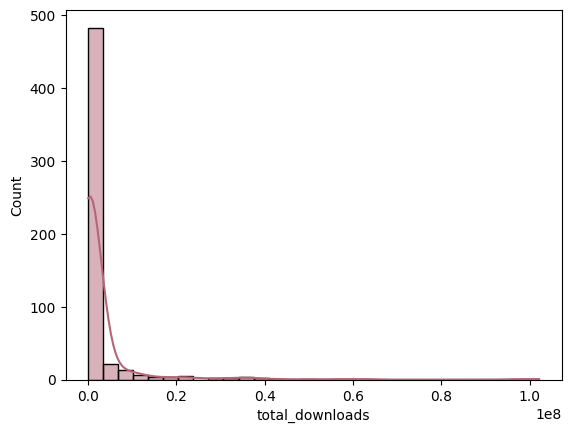

In [ ]:
#Distribution of Total downloads
sns.histplot(df_models['total_downloads'], bins=30, kde=True, color = '#b56576')

Insight :


* The histogram shows an extremely right-skewed distribution, where the majority of models have relatively low download counts clustered near zero, while a small number of models extend into very high download ranges.
*  The long right tail confirms the presence of significant outliers, reinforcing a winner-takes-all pattern in which only a few models capture disproportionately large user attention.





<Axes: xlabel='org_type', ylabel='count'>

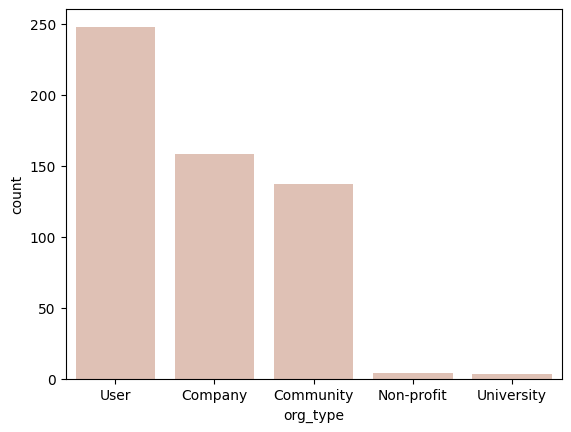

In [ ]:
#Organization Type Distribution
sns.countplot(x='org_type', data=df_models, color = '#e6beae')

Insight :
*  The chart indicates that most models are developed by individual users,
followed by companies and community groups, showing that independent creators play a dominant role in model contributions.
*  In contrast, non-profits and universities contribute very few models, suggesting limited institutional participation compared to individual and corporate contributors.



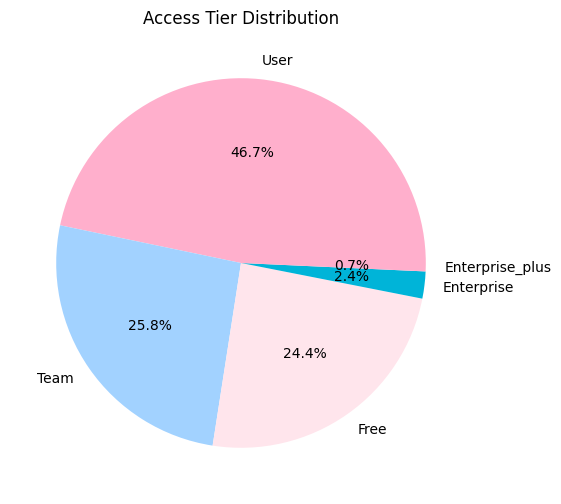

In [ ]:
#The actual users of models distribution
df_models['access_tier'].value_counts().plot(kind='pie', autopct='%1.1f%%',figsize=(6,6),colors=['#ffafcc', '#a2d2ff', '#ffe5ec', '#00b4d8'])
plt.title("Access Tier Distribution")
plt.ylabel('')
plt.show()

Insight :

* The distribution shows that individual consumers dominate usage (46.7%), indicating that nearly half of the models are primarily accessed at the individual level rather than organizational level.
* Enterprise adoption remains comparatively low (3.1% combined for Enterprise and Enterprise Plus), suggesting that large-scale corporate usage is still limited compared to consumer and team-based access.



<Axes: xlabel='variable', ylabel='count'>

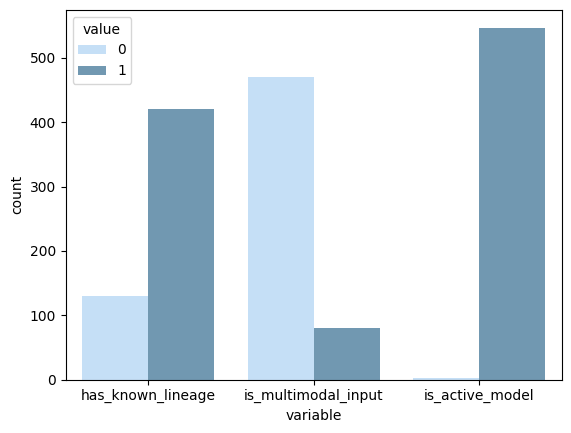

In [ ]:
# Boolean Features Distribution
sns.countplot(data=df_models.melt(value_vars=['has_known_lineage','is_multimodal_input','is_active_model']), x='variable', hue='value',
              palette={True: '#669bbc', False: '#bde0fe'} )

Insight :


*  The chart shows that most models have a known lineage (True), indicating that derivation or model inheritance is common, whereas multimodal input support is relatively rare, with the majority of models being unimodal.
*  Additionally, all models are active (100% True), suggesting the dataset is heavily skewed toward currently maintained or operational models rather than deprecated ones.





### Bi-Variant Analysis

<Axes: xlabel='annotator', ylabel='total_downloads'>

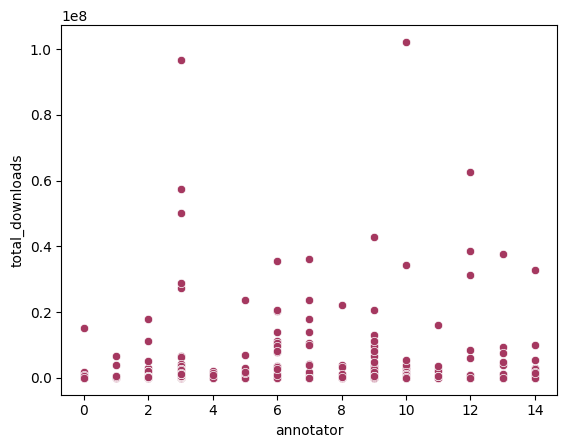

In [ ]:
#Downloads vs Annotators
sns.scatterplot(x='annotator', y='total_downloads', data=df_models, color='#a53860')

Insight :

* The scatter plot suggests that models developed by teams of around 5 to 10
annotators tend to achieve higher download counts, indicating that moderately sized teams may contribute to stronger model performance.
*  However, the presence of extreme outliers shows that while team size can be associated with higher downloads, success is not solely dependent on the number of annotators.



In [ ]:
#Top Country vs Downloads
top_country = (df_models.groupby('org_country')['total_downloads'].mean().sort_values(ascending=False).head(10).reset_index())
top_country = top_country.rename(columns={
    'org_country': 'Organization Country',
    'total_downloads': 'Total Downloads'
})

In [ ]:
fig = px.treemap(
    top_country,
    path=['Organization Country'],
    values='Total Downloads',
    color='Organization Country',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_layout(
    title="Top 10 Organization Countries by Average Total Downloads"
)
fig.show()


Insight :


*  The chart indicates that China has the highest average downloads per model, followed by Germany, the United States, and the United Kingdom, suggesting strong model performance from these regions.
*   This implies that certain countries may have stronger AI ecosystems or higher-performing flagship models that significantly boost their average download metrics.





In [ ]:
#Top Base Model Country vs Downloads
top_derived_country = (df_models.groupby('derived_model_country')['total_downloads'].mean().sort_values(ascending=False).head(10).reset_index())
top_derived_country = top_derived_country.rename(columns={
    'derived_model_country': 'Base Model Country',
    'total_downloads': 'Total Downloads'
})

In [ ]:
fig = px.treemap(
    top_derived_country,
    path=['Base Model Country'],
    values='Total Downloads',
    color='Base Model Country',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.update_layout(
    title="Top 10 Base Model Organization Countries by Average Total Downloads"
)
fig.show()


Insight :



*  The chart shows that base models originating from China have the highest average downstream downloads, followed by Israel and the United States, indicating that foundational models from these regions tend to generate strong derivative performance.
*  This suggests that the country of the original base model may influence the success of derived models, reflecting the global impact and quality of certain foundational AI ecosystems.




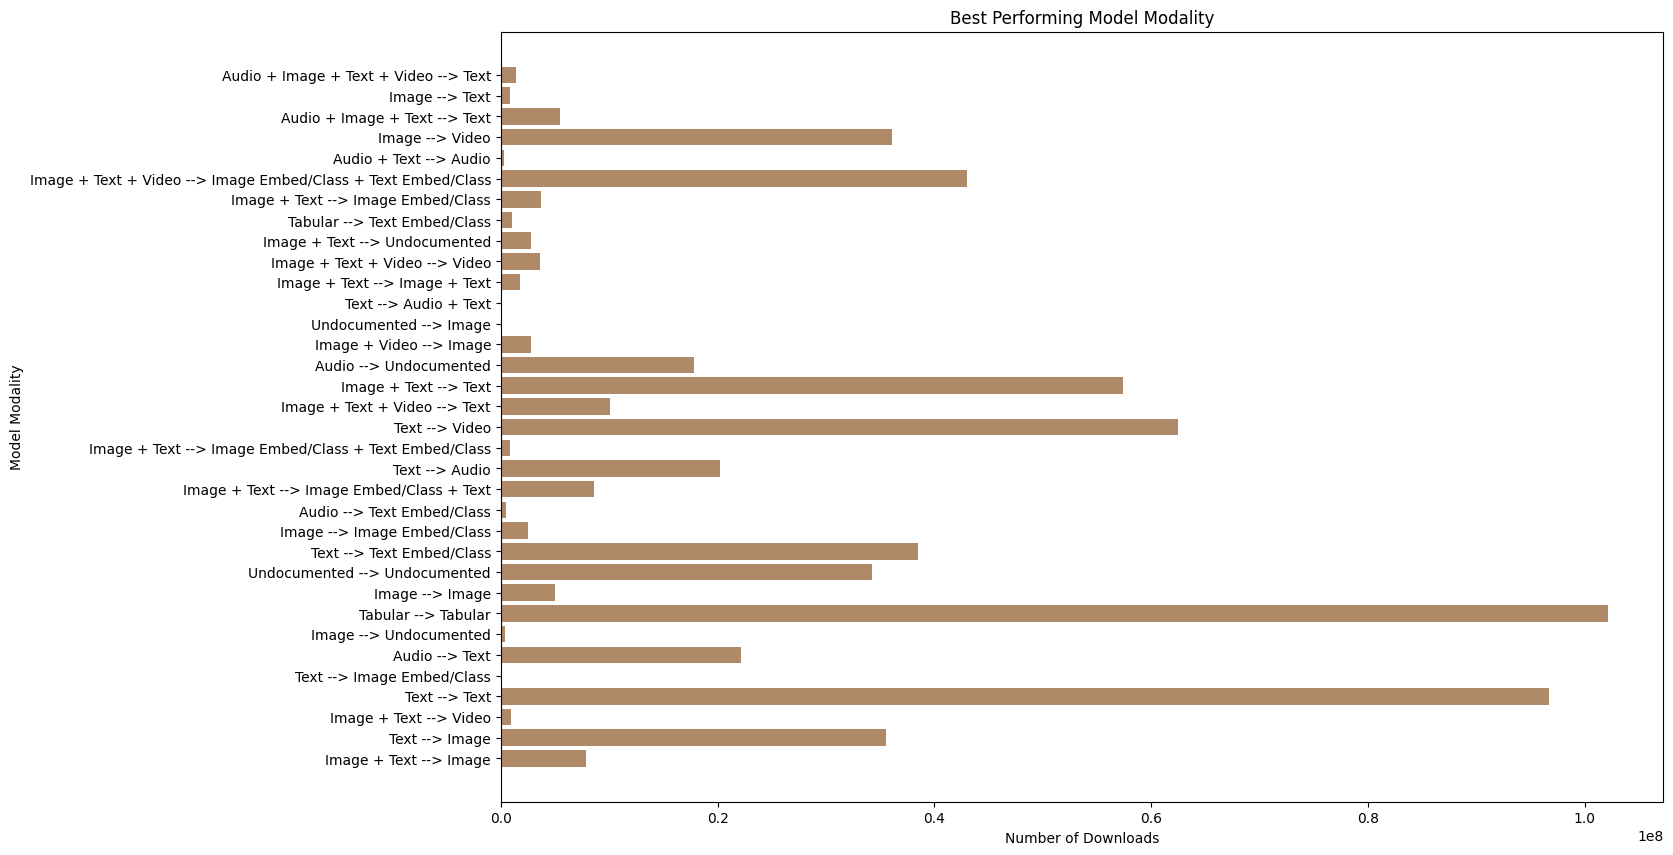

In [ ]:
#Downloads by Model Modality
plt.figure(figsize = (15,10))
plt.barh(df_models['model_modality'],df_models['total_downloads'], color = "#b08968")
plt.xlabel('Number of Downloads')
plt.ylabel('Model Modality')
plt.title('Best Performing Model Modality')
plt.show()

Insight :


*  The chart indicates that Tabular-to-Tabular, Text-to-Text, Text-to-Video, and Image+Text-to-Text modalities receive the highest download volumes, suggesting strong demand for data transformation, generative text, and multimodal applications.
*  This highlights that practical, widely applicable modalities—particularly those involving text processing and cross-modal generation—tend to dominate user adoption compared to more niche model types.




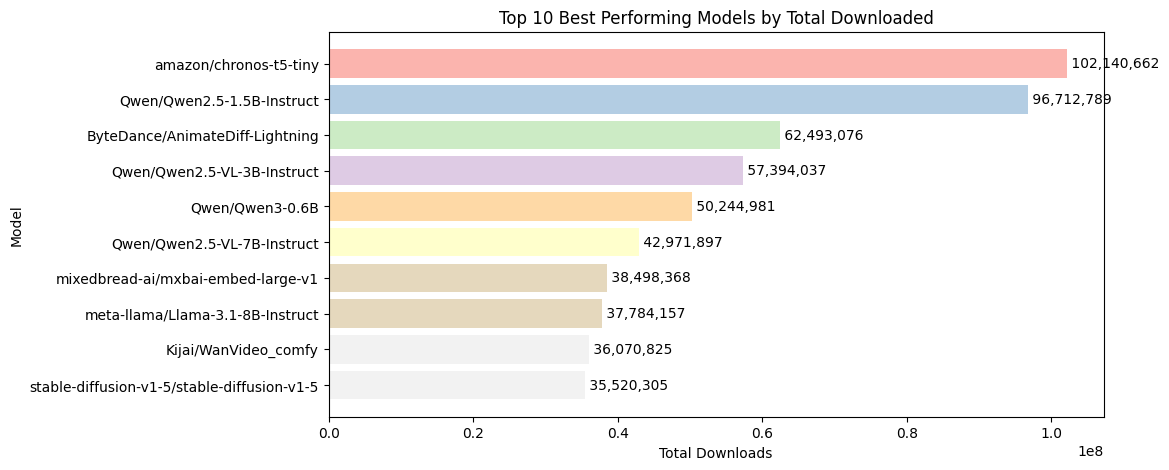

In [ ]:
# Top 10 best performing models
top10 = df_models.sort_values('total_downloads', ascending=False).head(10)

plt.figure(figsize=(10,5))
# Create soft pastel gradient
colors = plt.cm.Pastel1(np.linspace(0, 1, len(top10)))
bars = plt.barh(top10['model'], top10['total_downloads'], color=colors)

plt.xlabel("Total Downloads")
plt.ylabel("Model")
plt.title("Top 10 Best Performing Models by Total Downloaded")
plt.gca().invert_yaxis()

# Add download values next to bars
for i, v in enumerate(top10['total_downloads']):
    plt.text(v, i, f" {v:,}", va='center')

plt.show()


Insight :


*  The chart shows that amazon/chronos-t5-tiny leads as the most downloaded model, followed by Qwen/Qwen2.5/1.5B-Instruct, indicating strong dominance by a few flagship models in the ecosystem.
*  This reinforces the highly skewed distribution observed earlier, where a small number of top-performing models capture a disproportionately large share of total downloads.




### Multivariant Analysis

<Axes: xlabel='org_type', ylabel='total_downloads'>

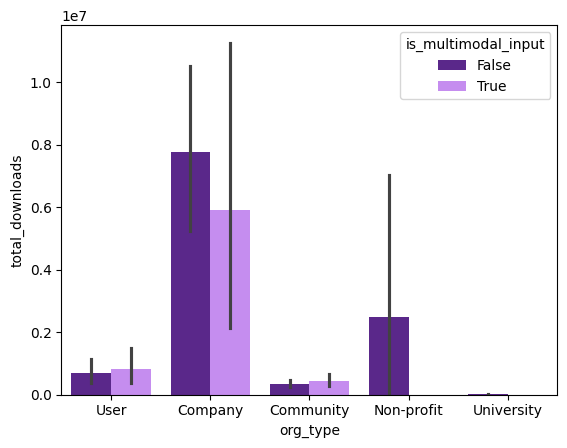

In [ ]:
#Does multimodel input have impact in downloads
sns.barplot(x='org_type', y='total_downloads', hue='is_multimodal_input', data=df_models, palette=['#5a189a','#c77dff'])

Insight :


*  The bar chart shows that company-developed models without multimodal input support (single-input models) achieve the highest download volumes, indicating that simpler, specialized architectures may currently drive stronger adoption.
* Similarly, non-profits and users also show higher downloads for unimodal models, suggesting that single-modality models remain more widely used and commercially impactful than multimodal ones in this dataset.





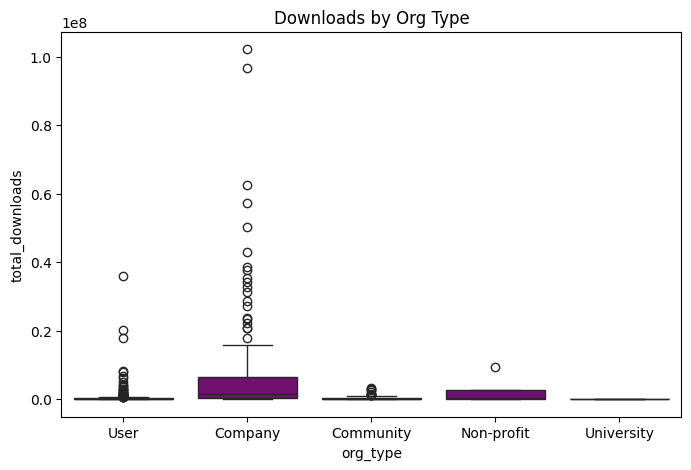

In [ ]:
#Boxplot: Organization Type vs Total Number of Downloads
plt.figure(figsize=(8,5))
sns.boxplot(data=df_models, x='org_type', y='total_downloads', color='purple')
plt.title("Downloads by Org Type")
plt.show()

Insight :



*  The boxplot indicates that company-developed models have the highest median downloads and the widest spread, along with numerous extreme outliers, suggesting that companies are more likely to produce blockbuster models.
*   Individual users also show notable outliers but with comparatively lower central tendency, while non-profits demonstrate more limited dispersion and overall lower download performance.




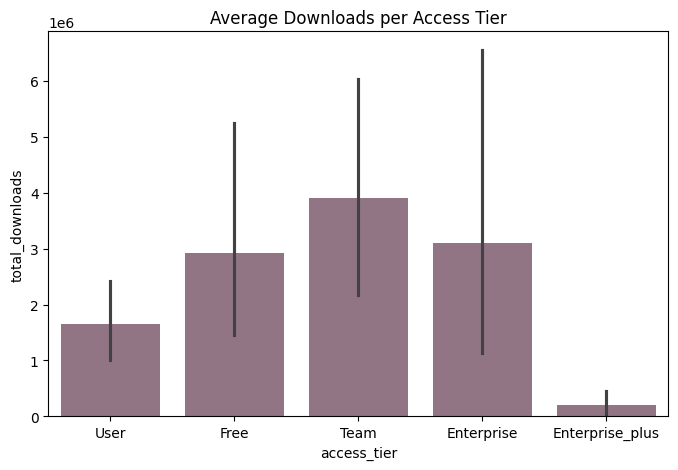

In [ ]:
#Barplot: Average Downloads based on accessors
plt.figure(figsize=(8,5))
sns.barplot(data=df_models, x='access_tier', y='total_downloads', color='#957186')
plt.title("Average Downloads per Access Tier")
plt.show()

Insight :


*  The bar chart shows that models under the Team access tier have the highest average downloads, followed by Enterprise and Free tiers, indicating stronger engagement among collaborative and organizational users.
*  In contrast, individual user and Enterprise Plus tiers exhibit lower average downloads, suggesting that structured or paid access environments may drive higher overall model utilization.




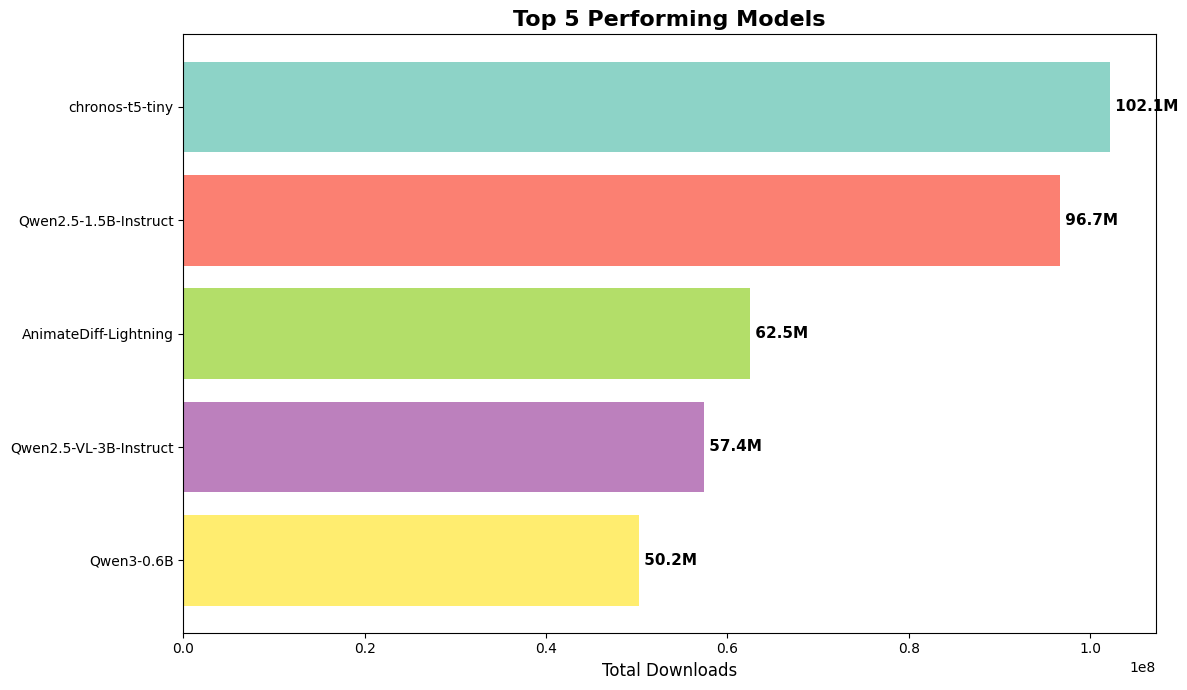

In [ ]:
# Get Top 5 models
top5 = df_models.sort_values('total_downloads', ascending=False).head(5)

plt.figure(figsize=(12, 7))

#Color Pallette
colors = plt.cm.Set3(np.linspace(0, 1, len(top5)))
bars = plt.barh(top5['model_name'], top5['total_downloads'], color=colors)

plt.xlabel("Total Downloads", fontsize=12)
plt.title("Top 5 Performing Models", fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()

# Clean Annotations (Only Downloads)
for i, downloads in enumerate(top5['total_downloads']):
    plt.text(downloads, i,
             f" {downloads/1e6:.1f}M",
             va='center',
             fontsize=11,
             fontweight='bold')

plt.tight_layout()
plt.show()

### Time Series Analysis

In [ ]:
#EDA
#Display top 5 rows
df_master.head()

,id,model,author,model_name,created,time,downloadsAllTime,org_country,org_type,model_modality,model_age_days,model_age_weeks,model_age_months,age_stage,weekly_growth,downloads_per_month
14150,6651802a815d7642d5aaef56,2Noise/ChatTTS,2Noise,ChatTTS,2024-05-25 06:07:38,2025-02-26,138273,User,User,Text --> Audio,276,39,9,Mature,0,"15,030"
14568,6651802a815d7642d5aaef56,2Noise/ChatTTS,2Noise,ChatTTS,2024-05-25 06:07:38,2025-03-05,139063,User,User,Text --> Audio,283,40,9,Mature,790,"14,742"
14945,6651802a815d7642d5aaef56,2Noise/ChatTTS,2Noise,ChatTTS,2024-05-25 06:07:38,2025-03-12,139702,User,User,Text --> Audio,290,41,10,Mature,639,"14,452"
15323,6651802a815d7642d5aaef56,2Noise/ChatTTS,2Noise,ChatTTS,2024-05-25 06:07:38,2025-03-19,140911,User,User,Text --> Audio,297,42,10,Mature,"1,209","14,233"
9650,6651802a815d7642d5aaef56,2Noise/ChatTTS,2Noise,ChatTTS,2024-05-25 06:07:38,2025-03-26,141501,User,User,Text --> Audio,304,43,10,Mature,590,"13,964"


In [ ]:
#Overall Summary of panel data
df_master.describe()

,created,time,downloadsAllTime,model_age_days,model_age_weeks,model_age_months,weekly_growth,downloads_per_month
count,19361,19361,"19,361","19,361","19,361","19,361","19,361","19,361"
mean,2025-01-09 21:23:25.934404096,2025-08-21 17:13:27.540932608,"2,019,290",223,31,7,"47,322","261,475"
min,2024-02-26 14:12:03,2025-02-26 00:00:00,0,-6,0,-0,"-572,957",0
25%,2024-10-25 06:24:15,2025-05-21 00:00:00,"16,346",158,22,5,13,"2,404"
50%,2025-01-20 14:52:51,2025-08-13 00:00:00,"195,057",236,33,8,453,"30,212"
75%,2025-04-07 18:47:10,2025-12-03 00:00:00,"831,487",300,42,10,"7,037","130,356"
max,2025-07-11 00:55:12,2026-02-01 00:00:00,"112,441,617",365,52,12,"8,048,896","17,902,508"
std,NaN,NaN,"7,076,267",93,13,3,"241,876","821,687"


In [ ]:
#Number of rows and columns
df_master.shape

(19361, 16)

In [ ]:
#Extracting year and month from time
df_master['year_month'] = df_master['time'].dt.to_period('M')

In [ ]:
#Checking for monthly growth of a model
df_master = df_master.sort_values(['model', 'time'])
df_master['monthly_growth'] = (df_master.groupby('model')['downloadsAllTime'].diff())


### Statistical Analysis

In [ ]:
#Extracting numerical values
numerical_column = df_master.select_dtypes(include=np.number)

In [ ]:
#Measure of Central Tendancy
central_tendancy_stat = pd.DataFrame({
    'Mean' : numerical_column.mean(),
    'Median' : numerical_column.median()
})
central_tendancy_stat

,Mean,Median
downloadsAllTime,"2,019,290","195,057"
model_age_days,223,236
model_age_weeks,31,33
model_age_months,7,8
weekly_growth,"47,322",453
downloads_per_month,"261,475","30,212"
monthly_growth,"48,706",519


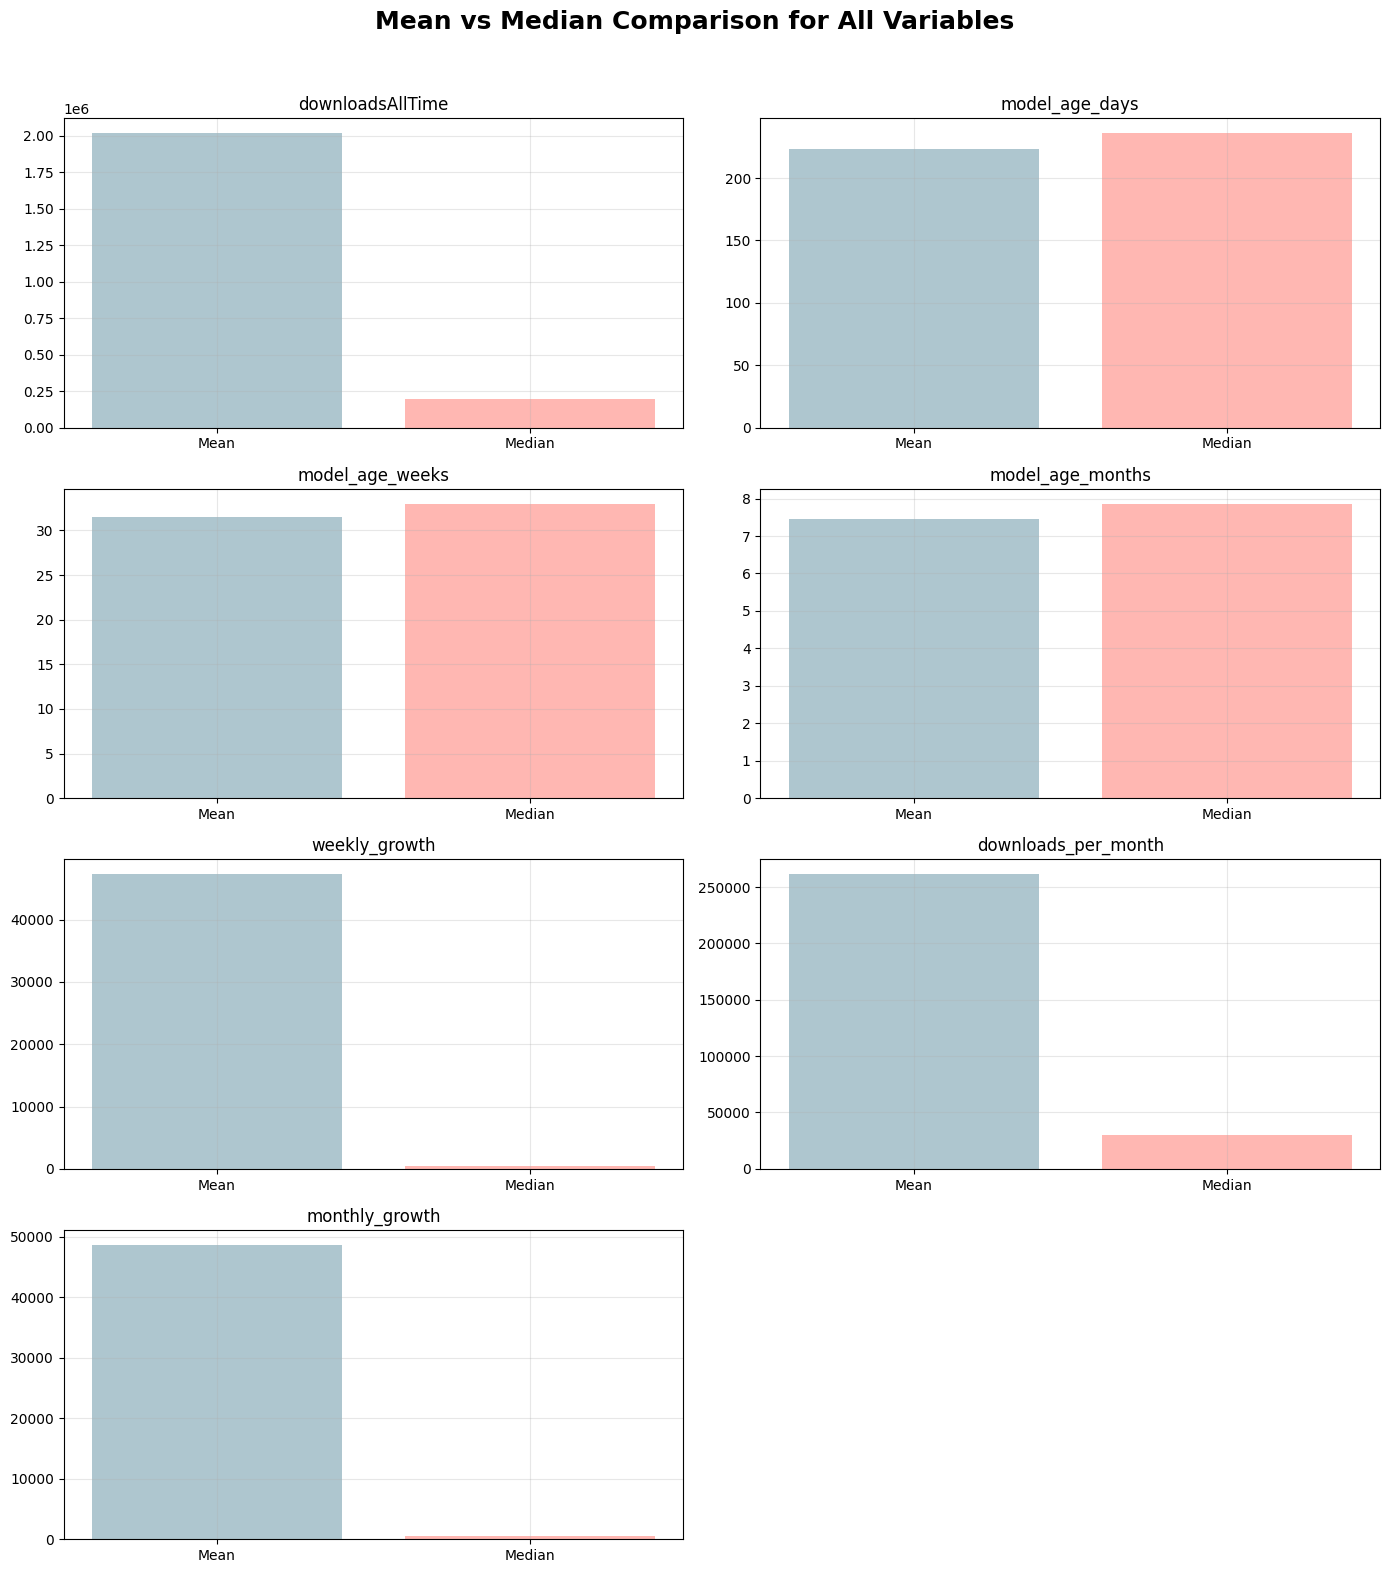

In [ ]:
#Visualizing Statisical Analysis
import math
#Collecting the number of columns in Statistical analysis
cols = central_tendancy_stat.index
n = len(cols)

#Divinding 2 visuals per row
rows = math.ceil(n / 2)

#Creating the surface for visualization
fig, axes = plt.subplots(rows, 2, figsize=(14, rows * 4))
#Heading
fig.suptitle("Mean vs Median Comparison for All Variables",
             fontsize=18, fontweight='bold')

axes = axes.flatten()

#A loop to run all the columns to display it's mean and median
for i, col in enumerate(cols):
    axes[i].bar(['Mean', 'Median'],
                central_tendancy_stat.loc[col],
                color=['#AEC6CF', '#FFB7B2'])

    axes[i].set_title(col)
    axes[i].grid(alpha=0.3)

# Remove extra empty plots
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
variance_std = pd.DataFrame({
    'Variance' : numerical_column.var(),
    'Standard Variation' : numerical_column.std()})
variance_std

,Variance,Standard Variation
downloadsAllTime,"50,073,547,783,141","7,076,267"
model_age_days,"8,690",93
model_age_weeks,177,13
model_age_months,10,3
weekly_growth,"58,503,870,129","241,876"
downloads_per_month,"675,169,582,893","821,687"
monthly_growth,"60,147,115,602","245,249"


In [ ]:
#Skewness and Kurtosis
skew_kurt_stat = pd.DataFrame({
      'Skewness' : numerical_column.skew(),
    'Kurtosis' : numerical_column.kurt()})
skew_kurt_stat

,Skewness,Kurtosis
downloadsAllTime,7,77
model_age_days,-0,-1
model_age_weeks,-0,-1
model_age_months,-0,-1
weekly_growth,12,231
downloads_per_month,8,98
monthly_growth,12,225


<Figure size 1500x800 with 0 Axes>

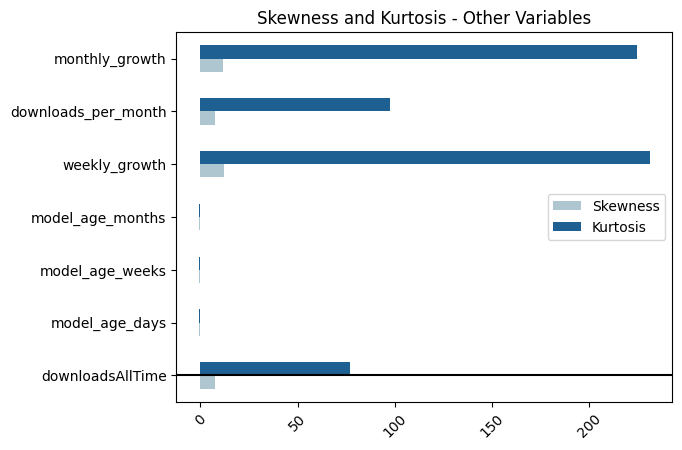

In [ ]:
#Skewness and Kurtosis Distribution
plt.figure(figsize=(15,8))
skew_kurt_stat[['Skewness', 'Kurtosis']].plot(kind='barh' , color=['#AEC6CF', '#1e6091'])
plt.title("Skewness and Kurtosis - Other Variables")
plt.xticks(rotation=45)
plt.axhline(0, color='black')
plt.show()

Performance Metrics (Downloads & Growth)

*   Extremely right-skewed
*   Heavy-tailed
*   Outlier-dominated
*   Power-law behavior

Age & Timing Metrics

*  Stable
*  Symmetric
*  Normally distributed

  Insight : Time-series metrics reveal extreme positive skewness and heavy-tailed distributions in downloads and growth variables, indicating concentrated market dominance by a small subset of models. In contrast, lifecycle variables such as model age and peak timing exhibit near-symmetric distributions, suggesting structural stability in model release patterns despite unequal performance outcomes.

### Univariant Analysis

Text(0.5, 1.0, 'Cumulative Downloads Over Time')

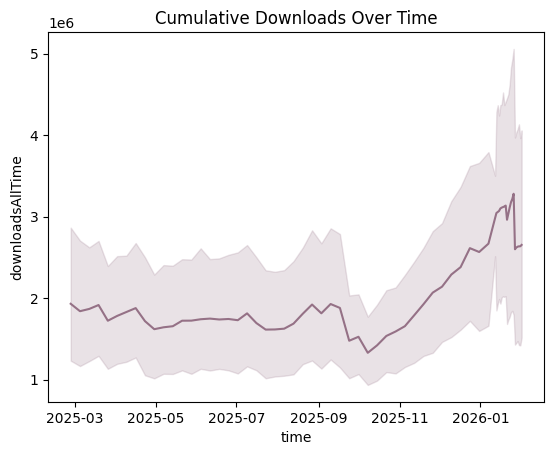

In [ ]:
#Cummulative Download Trend
sns.lineplot(data=df_master, x='time', y='downloadsAllTime', color='#957186')
plt.title("Cumulative Downloads Over Time")

Insight : The cumulative download trend remains relatively steady from March 2025 to September 2025, indicating a stable growth phase with consistent user adoption. However, a sharp increase around January 2026 suggests a sudden surge in downloads, possibly driven by the release of high-performing models or increased platform traction during that period.

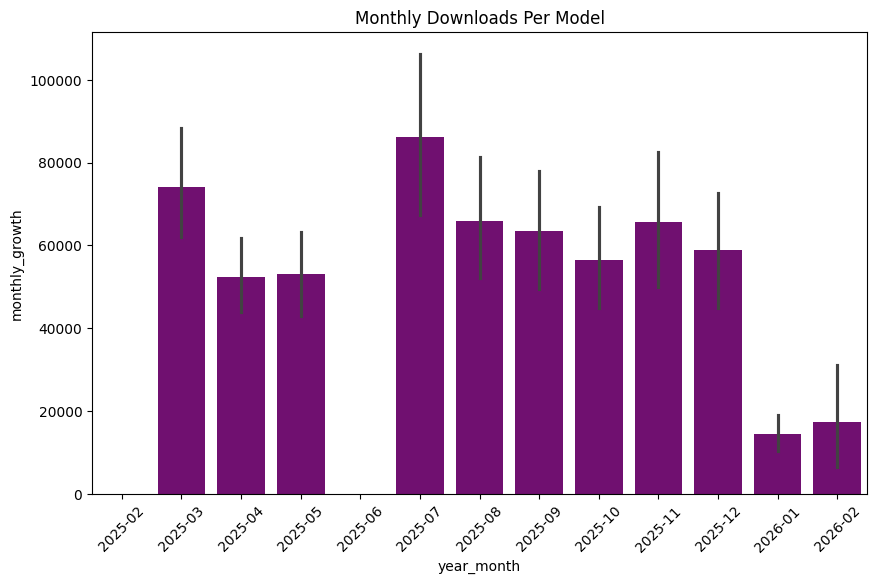

In [ ]:
#Monthly Downloads Per Model
plt.figure(figsize=(10,6))
sns.barplot(data=df_master,x='year_month',y='monthly_growth',color = 'purple')
plt.xticks(rotation=45)
plt.title("Monthly Downloads Per Model")
plt.show()

Insight :



*  The monthly downloads trend indicates that July 2025 recorded the highest model growth, followed by March 2025 and November 2025, highlighting key periods of elevated user activity.
*  These peaks suggest seasonal or release-driven surges in adoption, where specific months experienced significantly stronger download momentum compared to others.




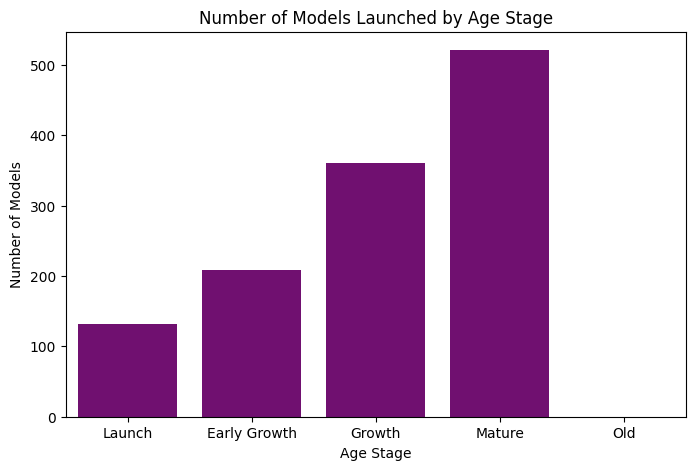

In [ ]:
#Number of Models Launched by Age Stage
age_stage_counts = (df_master.groupby('age_stage')['model_name'].nunique().reset_index(name='num_models'))

plt.figure(figsize=(8,5))
sns.barplot(data=age_stage_counts,x='age_stage',y='num_models', color='purple')

plt.title("Number of Models Launched by Age Stage")
plt.xlabel("Age Stage")
plt.ylabel("Number of Models")
plt.show()

Insight :



* The distribution shows that most models fall into the Mature stage, followed by Growth and Early Growth, indicating that the ecosystem is largely composed of established models rather than newly launched ones.
* The relatively smaller proportion in the Launch stage suggests fewer newly introduced models compared to those that have already progressed through their lifecycle.




### Bivariant Analysis

<Axes: xlabel='time', ylabel='weekly_growth'>

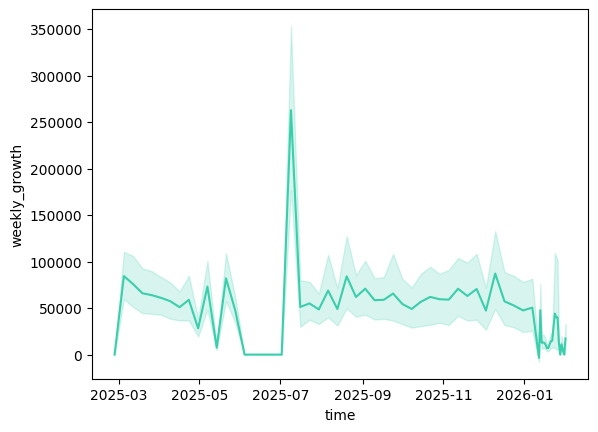

In [ ]:
#Time vs Weekly Growth
sns.lineplot(data=df_master, x='time', y='weekly_growth', color='#3bceac')

Insight : The weekly growth trend reaches its highest peak around July 2025, indicating a strong surge in short-term adoption during that period. Afterward, growth declines and stabilizes by January 2026, suggesting a transition from rapid expansion to a more steady and consistent growth phase.

<Axes: xlabel='age_stage', ylabel='weekly_growth'>

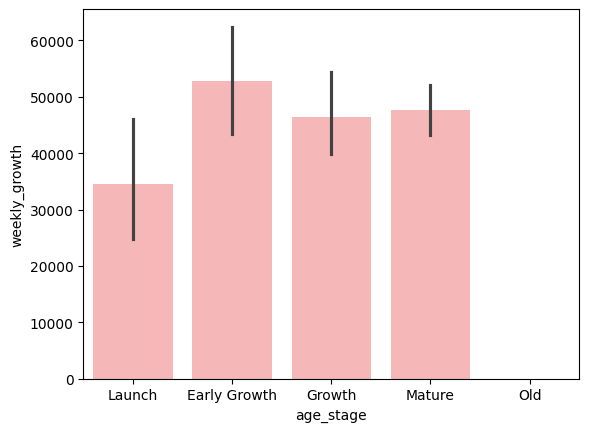

In [ ]:
#Age stage vs Weekly Growth
sns.barplot(x='age_stage', y='weekly_growth', data=df_master, color = '#ffadad')

Insight :


*  The bar chart shows that models in the Early Growth stage have the highest average weekly growth, indicating that momentum tends to build shortly after launch rather than immediately at release.
*  Mature models still maintain relatively strong growth compared to Launch-stage models, suggesting that sustained adoption can continue well beyond the initial introduction phase.







### Multivariant Analysis

<Axes: xlabel='time', ylabel='downloads_per_month'>

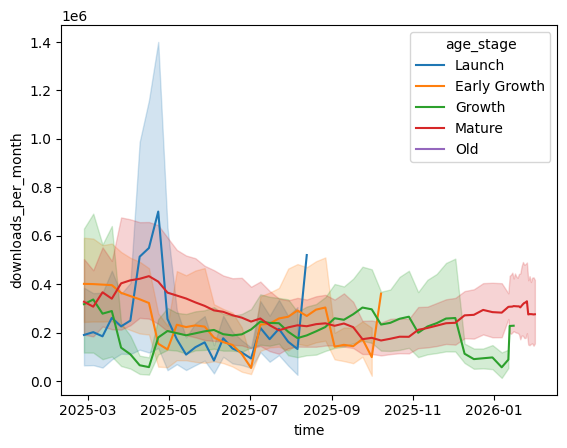

In [ ]:
# Time vs Downloads vs Growth
sns.lineplot(data=df_master,x='time',y='downloads_per_month',hue='age_stage')

Insight :



* The line plot indicates that models in the Launch stage record the highest monthly downloads, suggesting strong initial adoption immediately after release
* However, as models transition into Growth and Mature stages, download momentum becomes more stabilized, reflecting a shift from early hype-driven spikes to sustained usage patterns.



<Axes: xlabel='model_age_weeks', ylabel='weekly_growth'>

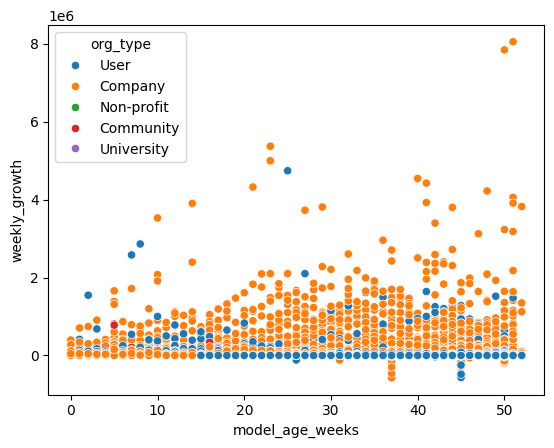

In [ ]:
#Age vs Organization Type vs Growth
sns.scatterplot(data=df_master,x='model_age_weeks',y='weekly_growth',hue='org_type')

Insight :


*  The scatter plot shows that company-developed models exhibit the highest and most concentrated weekly growth, indicating stronger and more sustained performance compared to other organization types.
*  In contrast, user-developed models cluster near zero growth, while notable outliers around 50 weeks suggest that some mature company models experience significant growth spikes even at later lifecycle stages.







<Axes: xlabel='org_type', ylabel='age_stage'>

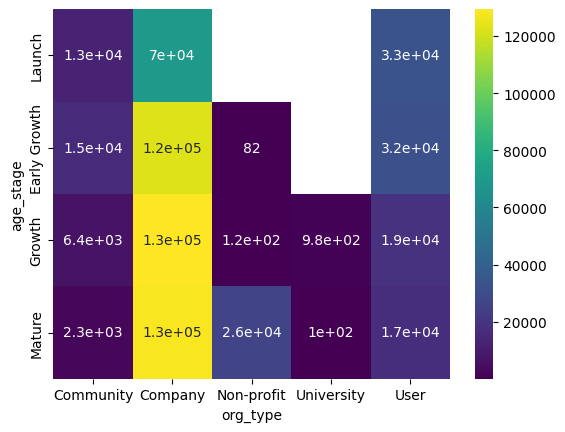

In [ ]:
# Age Stage vs Organization Type vs Avg Growth
pivot = df_master.pivot_table(values='weekly_growth',index='age_stage',columns='org_type',aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='viridis')

Insight :


* The heatmap shows that company-developed models consistently achieve the highest average weekly growth across almost all age stages, particularly in the Growth and Mature stages, indicating sustained performance beyond initial release.
* In contrast, community, university, and non-profit models exhibit comparatively lower average growth, while user-developed models maintain moderate growth, suggesting that organizational backing—especially from companies—plays a significant role in driving long-term model momentum.







---